# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_1_1_Split_Structure

- 무작위 분할이 왜 낙관적인지 규명 (분할 구조 진단)
- 평가 프로토콜: 진단 목적. CV 그룹 단위를 바꿔가며 비교하며, 모델 후보 선택에는 쓰지 않음
- 주의: 여기 수치는 04_6 · 07_2 수치를 **해석하는 근거**. 성능 보고에 직접 쓰지 않음

## import

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score
from sklearn.model_selection import (StratifiedGroupKFold, StratifiedKFold,
                                     cross_val_predict, cross_val_score,
                                     train_test_split)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT=Path.cwd().parent if Path.cwd().name=='data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 경로설정

In [2]:
if Path.cwd().name!='data':
    os.chdir('data')

## 데이터 불러오기

- 02_EDA가 저장한 전처리 데이터 사용
- 시간 정보는 분할 기준으로만 쓰고 모델 입력에서는 제외

In [3]:
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

time_stamp=pd.to_datetime(model_data['TimeStamp'])
production_date=time_stamp.dt.date
window_10min=time_stamp.dt.floor('10min')
window_1hour=time_stamp.dt.floor('1h')
lot_id=(model_data['PART_FACT_PLAN_DATE'].astype(str)+'_'+model_data['PART_FACT_SERIAL'].astype(str))

drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']
final_df=model_data.drop(columns=drop_columns)

X_part=pd.get_dummies(final_df.drop(columns='PassOrFail'), columns=['Part'], drop_first=True, dtype=int)
Y=final_df['PassOrFail']

print(f'{len(X_part)}행 {X_part.shape[1]}특성 / 불량 {Y.sum()}건 (기저 {Y.mean():.4f})')
print(f'생산일 {production_date.nunique()}개, 10분 구간 {window_10min.nunique()}개, '
      f'1시간 구간 {window_1hour.nunique()}개, lot {lot_id.nunique()}개')

5230행 26특성 / 불량 60건 (기저 0.0115)
생산일 13개, 10분 구간 282개, 1시간 구간 59개, lot 23개


## 1. 공정 조건만으로 시간 구간을 알아낼 수 있는가

**무작위 K-Fold는 행이 서로 독립이라고 가정하는데, 이 데이터는 그 가정이 깨짐**
- 공정 변수만으로 그 행이 언제 생산됐는지 맞히는 분류기를 학습
- 잘 맞힌다면 행이 시간 구간 단위로 뭉쳐 있다는 뜻
- 무작위 기준(1 ÷ 클래스 수)과 비교

In [4]:
N_SPLITS=3

identify_model=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=0)),
])

identify_rows=[]
for target_name, target in [('생산일', pd.Series(production_date.astype(str)).to_numpy()),
                            ('1시간 구간', window_1hour.astype(str).to_numpy()),
                            ('10분 구간', window_10min.astype(str).to_numpy())]:
    counts=pd.Series(target).value_counts()
    keep=pd.Series(target).isin(counts[counts>=N_SPLITS].index).to_numpy()
    accuracy=cross_val_score(clone(identify_model), X_part[keep], target[keep],
                             cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0),
                             scoring='accuracy', n_jobs=-1).mean()
    n_class=pd.Series(target[keep]).nunique()
    identify_rows.append({'맞히려는 것': target_name, '클래스 수': n_class,
                          '분류 정확도': round(accuracy, 4), '무작위 기준': round(1/n_class, 4),
                          '기준 대비': round(accuracy*n_class, 1)})

identify_df=pd.DataFrame(identify_rows)
identify_df

,맞히려는 것,클래스 수,분류 정확도,무작위 기준,기준 대비
0,생산일,11,0.9987,0.0909,11.0
1,1시간 구간,57,0.9315,0.0175,53.1
2,10분 구간,276,0.7952,0.0036,219.5


### 개별 변수가 아니라 조합이 구분

- 변수를 하나씩 늘려가며 생산일 분류 정확도를 확인
- 한 변수만으로도 어느 정도 맞히지만, 몇 개만 합치면 거의 완벽해짐

In [5]:
cumulative=['Plasticizing_Time', 'Plasticizing_Position', 'Average_Screw_RPM',
            'Mold_Temperature_3', 'Mold_Temperature_4']
date_target=pd.Series(production_date.astype(str)).to_numpy()

date_counts=pd.Series(date_target).value_counts()
date_keep=pd.Series(date_target).isin(date_counts[date_counts>=N_SPLITS].index).to_numpy()

cumulative_rows=[]
for k in range(1, len(cumulative)+1):
    use=cumulative[:k]
    accuracy=cross_val_score(clone(identify_model), X_part[use][date_keep], date_target[date_keep],
                             cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0),
                             scoring='accuracy', n_jobs=-1).mean()
    cumulative_rows.append({'사용 변수 수': k, '추가한 변수': use[-1], '생산일 분류 정확도': round(accuracy, 4)})

# lot 단위로 세팅되므로 변수마다 고유값이 많음
unique_counts=(X_part[[c for c in X_part.columns if not c.startswith('Part_')]]
               .nunique().sort_values(ascending=False).head(8))

print('변수별 고유값 수 상위 8개')
print(unique_counts.to_string())
pd.DataFrame(cumulative_rows)

변수별 고유값 수 상위 8개
Plasticizing_Time           119
Hopper_Temperature           92
Barrel_Temperature_4         78
Max_Switch_Over_Pressure     67
Barrel_Temperature_1         66
Average_Back_Pressure        61
Barrel_Temperature_2         58
Max_Back_Pressure            56


,사용 변수 수,추가한 변수,생산일 분류 정확도
0,1,Plasticizing_Time,0.7276
1,2,Plasticizing_Position,0.9284
2,3,Average_Screw_RPM,0.9328
3,4,Mold_Temperature_3,0.9895
4,5,Mold_Temperature_4,0.9975


### 같은 구간 안의 행은 서로 붙어 있음

- 표준화 공간에서 각 행의 최근접 이웃이 같은 날에 속하는 비율을 확인
- 같은 lot 안의 평균 거리와 다른 lot 과의 평균 거리도 비교

In [6]:
X_scaled=StandardScaler().fit_transform(X_part)

neighbor=NearestNeighbors(n_neighbors=6).fit(X_scaled)
_, indices=neighbor.kneighbors(X_scaled)
neighbor_idx=indices[:, 1:]

date_array=np.asarray(production_date.astype(str))
same_day=(date_array[neighbor_idx]==date_array[:, None]).mean(axis=1)

print(f'최근접 5개 이웃 중 같은 날 비율 - 전체 행 {same_day.mean():.3f}, '
      f'불량 행 {same_day[Y.to_numpy()==1].mean():.3f}')

# lot 내부 거리 대 lot 간 거리
rng=np.random.default_rng(0)
lot_array=np.asarray(lot_id)
within, between=[], []
for lot in pd.Series(lot_array).value_counts().head(30).index:
    inside=np.where(lot_array==lot)[0]
    outside=np.where(lot_array!=lot)[0]
    if len(inside)<5:
        continue
    pick=rng.choice(inside, size=min(30, len(inside)), replace=False)
    other=rng.choice(outside, size=200, replace=False)
    within.append(np.linalg.norm(X_scaled[pick][:, None]-X_scaled[pick][None], axis=2).mean())
    between.append(np.linalg.norm(X_scaled[pick][:, None]-X_scaled[other][None], axis=2).mean())

print(f'같은 lot 안 평균 거리 ÷ 다른 lot 과의 거리 = {np.mean(within)/np.mean(between):.2f}')

최근접 5개 이웃 중 같은 날 비율 - 전체 행 0.956, 불량 행 0.967
같은 lot 안 평균 거리 ÷ 다른 lot 과의 거리 = 0.24


## 2. 모델이 하는 일은 결국 구간 식별

**공정 변수를 전혀 쓰지 않고 "이 행이 속한 10분 구간의 불량률"만 점수로 써서 AP를 계산**
- 이 점수가 실제 모델의 무작위 5-fold AP와 비슷하다면, 모델이 하는 일이 구간 식별로 설명됨
- 자기 자신을 포함한 불량률은 정답을 일부 보는 셈이므로, 자기 행을 뺀 값도 함께 계산

In [7]:
window_key=window_10min.to_numpy()
y_array=Y.to_numpy()

window_sum=pd.Series(y_array).groupby(window_key).transform('sum').to_numpy()
window_size=pd.Series(y_array).groupby(window_key).transform('size').to_numpy()

rate_with_self=window_sum/window_size

# 자기 행을 뺀 값. 구간에 행이 하나뿐이면 0으로 둠
other_sum=window_sum-y_array
other_size=window_size-1
rate_without_self=np.divide(other_sum, other_size, out=np.zeros(len(y_array), dtype=float),
                            where=other_size>0)

final_model=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                  class_weight='balanced', n_jobs=-1, random_state=0)),
])

random_cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
model_proba=cross_val_predict(clone(final_model), X_part, Y, cv=random_cv,
                              method='predict_proba', n_jobs=-1)[:, 1]

baseline_rows=[
    {'점수': '10분 구간 불량률 (자기 포함)', '공정 변수 사용': 'X',
     'AP': round(average_precision_score(Y, rate_with_self), 4)},
    {'점수': '10분 구간 불량률 (자기 제외)', '공정 변수 사용': 'X',
     'AP': round(average_precision_score(Y, rate_without_self), 4)},
    {'점수': 'RandomForest Balanced 무작위 5-fold', '공정 변수 사용': 'O',
     'AP': round(average_precision_score(Y, model_proba), 4)},
]
pd.DataFrame(baseline_rows)

,점수,공정 변수 사용,AP
0,10분 구간 불량률 (자기 포함),X,0.3842
1,10분 구간 불량률 (자기 제외),X,0.2728
2,RandomForest Balanced 무작위 5-fold,O,0.3910


## 3. CV 그룹 단위를 넓히면 성능이 사라짐

- 같은 모델을 그대로 두고 **분할 그룹만** 바꿔가며 비교
- 그룹이 넓어질수록 학습에서 본 구간이 검증에 없으므로, 구간 식별로 얻던 성능이 빠짐

In [8]:
group_rows=[]

ap=average_precision_score(Y, model_proba)
group_rows.append({'CV 그룹 단위': '없음 (무작위)', '그룹 수': np.nan,
                   'AP': round(ap, 4), '기저 대비': round(ap/Y.mean(), 1)})

for group_name, group in [('10분', window_10min.astype(str)),
                          ('1시간', window_1hour.astype(str)),
                          ('생산일', pd.Series(production_date.astype(str), index=Y.index))]:
    cv=StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
    proba=cross_val_predict(clone(final_model), X_part, Y, cv=cv, groups=group.to_numpy(),
                            method='predict_proba', n_jobs=-1)[:, 1]
    ap=average_precision_score(Y, proba)
    group_rows.append({'CV 그룹 단위': group_name, '그룹 수': group.nunique(),
                       'AP': round(ap, 4), '기저 대비': round(ap/Y.mean(), 1)})

group_df=pd.DataFrame(group_rows)
group_df

,CV 그룹 단위,그룹 수,AP,기저 대비
0,없음 (무작위),NaN,0.3910,34.1
1,10분,282.0,0.0984,8.6
2,1시간,59.0,0.0638,5.6
3,생산일,13.0,0.0198,1.7


## 4. 에피소드 안의 위치를 알려주는 특성은 넣지 않음

**시간축 특성을 넣으면 무작위 분할에서만 좋아짐**
- `lot_shot_index`(lot 안에서 몇 번째 샷인지)와 `session_shot_index`를 만들어 중요도를 확인
- 공정 물리가 아니라 에피소드 안의 위치 정보이며, 같은 lot이 학습에 있을 때만 유효한 단서
- 04_1의 파생변수 실험(AP 0.645 → 0.453)과 함께 이 계열을 채택하지 않는 근거로 씀

In [9]:
order=time_stamp.sort_values(kind='mergesort').index

position_df=pd.DataFrame(index=order)
position_df['lot_shot_index']=pd.Series(lot_id).loc[order].groupby(pd.Series(lot_id).loc[order]).cumcount()

gap=time_stamp.loc[order].diff()
session=(gap>pd.Timedelta(minutes=5)).cumsum()
position_df['session_shot_index']=session.groupby(session).cumcount()

X_position=X_part.loc[order].join(position_df)
Y_position=Y.loc[order]

diagnostic=clone(final_model).fit(X_position, Y_position)
importance=pd.Series(diagnostic.named_steps['rf'].feature_importances_,
                     index=X_position.columns).sort_values(ascending=False)

print('특성 중요도 상위 10개')
importance.head(10).round(4)

특성 중요도 상위 10개


session_shot_index        0.1062
lot_shot_index            0.1031
Plasticizing_Position     0.0720
Mold_Temperature_4        0.0497
Max_Back_Pressure         0.0490
Part_RG3RH                0.0452
Part_RG3LH                0.0450
Max_Injection_Pressure    0.0437
Plasticizing_Time         0.0389
Mold_Temperature_3        0.0379
dtype: float64

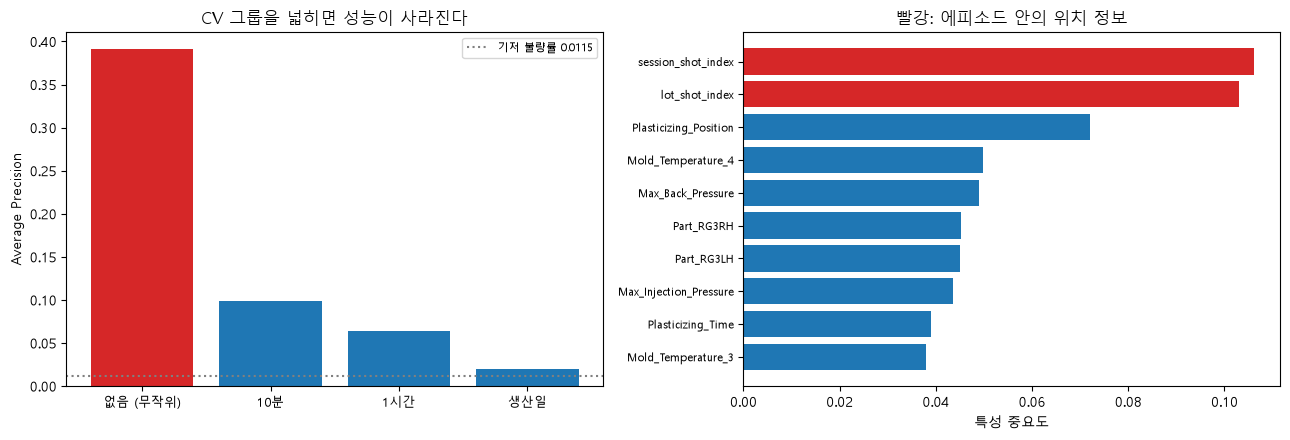

In [10]:
fig, axes=plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(len(group_df)), group_df['AP'], color=['tab:red']+['tab:blue']*3)
axes[0].set_xticks(range(len(group_df)))
axes[0].set_xticklabels(group_df['CV 그룹 단위'], fontsize=9)
axes[0].axhline(Y.mean(), color='gray', linestyle=':', label=f'기저 불량률 {Y.mean():.4f}')
axes[0].set_ylabel('Average Precision')
axes[0].set_title('CV 그룹을 넓히면 성능이 사라짐')
axes[0].legend(fontsize=8)

top=importance.head(10)[::-1]
colors=['tab:red' if name.endswith('shot_index') else 'tab:blue' for name in top.index]
axes[1].barh(range(len(top)), top.to_numpy(), color=colors)
axes[1].set_yticks(range(len(top)))
axes[1].set_yticklabels(top.index, fontsize=8)
axes[1].set_xlabel('특성 중요도')
axes[1].set_title('빨강: 에피소드 안의 위치 정보')

plt.tight_layout()
plt.show()

## 5. 분할 시드와 학습량도 성능을 흔듦

**같은 데이터 · 같은 모델인데 평가 설계만 바꿔도 AP가 크게 달라짐**
- 04_2 · 04_5가 쓴 `random_state=0` 80/20 분할이 유리한 분할이었는지 확인
- 04_2 OOF(0.26)와 04_6 CV(0.39)의 차이가 학습량 때문인지 확인
- 두 실험 모두 진단 목적이며, 보고 수치로 쓰지 않음


### 5-1. 분할 시드를 바꾸면 holdout AP가 얼마나 변하는가

- 80/20 층화 분할의 시드를 0 ~ 9로 바꿔가며 test AP를 측정
- 비교를 위해 **모델 시드만** 바꾼 경우도 함께 측정


In [11]:
split_model=Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=4,
                                  class_weight='balanced', n_jobs=-1, random_state=0)),
])

# 분할 시드만 변경
split_seed_rows=[]
for seed in range(10):
    X_train, X_test, y_train, y_test=train_test_split(
        X_part, Y, test_size=0.2, stratify=Y, random_state=seed)
    proba=clone(split_model).fit(X_train, y_train).predict_proba(X_test)[:, 1]
    split_seed_rows.append({'분할 시드': seed, 'test 불량 수': int(y_test.sum()),
                            'holdout AP': round(average_precision_score(y_test, proba), 4)})

split_seed_df=pd.DataFrame(split_seed_rows)
split_seed_df['순위']=split_seed_df['holdout AP'].rank(ascending=False).astype(int)

# 모델 시드만 변경 (분할은 random_state=0 고정)
X_train, X_test, y_train, y_test=train_test_split(
    X_part, Y, test_size=0.2, stratify=Y, random_state=0)
model_seed_rows=[]
for seed in range(5):
    model=Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_leaf=4,
                                      class_weight='balanced', n_jobs=-1, random_state=seed)),
    ])
    proba=model.fit(X_train, y_train).predict_proba(X_test)[:, 1]
    model_seed_rows.append({'모델 시드': seed,
                            'holdout AP': round(average_precision_score(y_test, proba), 4)})

model_seed_df=pd.DataFrame(model_seed_rows)

print(f"분할 시드 변경 - AP {split_seed_df['holdout AP'].min():.4f} ~ {split_seed_df['holdout AP'].max():.4f}"
      f" / 평균 {split_seed_df['holdout AP'].mean():.4f} / 폭 {split_seed_df['holdout AP'].max()-split_seed_df['holdout AP'].min():.4f}")
print(f"  random_state=0 은 10개 중 {int(split_seed_df.loc[split_seed_df['분할 시드']==0, '순위'].iloc[0])}위")
print(f"모델 시드 변경 - AP {model_seed_df['holdout AP'].min():.4f} ~ {model_seed_df['holdout AP'].max():.4f}"
      f" / 폭 {model_seed_df['holdout AP'].max()-model_seed_df['holdout AP'].min():.4f}")
split_seed_df.sort_values('holdout AP', ascending=False)


분할 시드 변경 - AP 0.1875 ~ 0.5695 / 평균 0.3378 / 폭 0.3820
  random_state=0 은 10개 중 1위
모델 시드 변경 - AP 0.5116 ~ 0.5695 / 폭 0.0579


,분할 시드,test 불량 수,holdout AP,순위
0,0,12,0.5695,1
5,5,12,0.4644,2
7,7,12,0.3848,3
8,8,12,0.3765,4
1,1,12,0.3401,5
3,3,12,0.3325,6
6,6,12,0.3207,7
4,4,12,0.2033,8
2,2,12,0.1985,9
9,9,12,0.1875,10


**분할 시드 하나만 바꿔도 AP가 0.19 ~ 0.57로 변함**

| 무엇을 바꿨나 | AP 범위 | 폭 |
| --- | --- | --- |
| **분할 시드** (test set 구성) | 0.1875 ~ 0.5695 | **0.3820** |
| 모델 시드 (분할 고정) | 0.5116 ~ 0.5695 | 0.0579 |

- **04_2 · 04_5가 쓴 `random_state=0`은 10개 중 1위**였음. 가장 유리한 분할을 뽑아 쓴 셈
- 10개 시드 평균은 **0.3378**로, 04_6의 반복 CV 평균(0.3931)과 같은 자릿수임. 즉 **0.57이 아니라 0.34 근처가 이 데이터의 실제 수준**
- 분할 시드 폭(0.382)이 모델 시드 폭(0.058)의 **6.6배**임. 성능 차이를 논할 때 모델보다 **평가 설계가 훨씬 크게 작용**함
- test set이 1046건 / 불량 12건뿐이라 **불량 1건이 AP를 크게 움직임**. 단일 holdout 수치를 보고하면 안 되는 이유임


### 5-2. 학습량을 줄이면 성능이 얼마나 떨어지는가

- 5-fold OOF를 그대로 두고 **fold 안 학습 부분만** 층화 축소해 AP를 측정
- 3347행은 04_2의 fold별 학습량, 4184행은 04_6의 fold별 학습량에 해당
- 반복 3회 평균으로 측정 노이즈를 줄임


**학습량을 줄이면 AP가 단조 감소함**

| fold별 학습 행 | fold별 학습 불량 | OOF AP | 표준편차 |
| --- | --- | --- | --- |
| 1673 | 19 | 0.1673 | 0.0240 |
| 2510 | 29 | 0.2539 | 0.0250 |
| **3347** (04_2 조건) | 38 | 0.3387 | 0.0416 |
| **4184** (04_6 조건) | 48 | 0.3691 | 0.0157 |

- 학습 행이 1673 → 4184로 2.5배가 되면 AP가 **0.167 → 0.369로 2.2배**가 됨. 불량 19건 → 48건 구간에서는 **데이터가 늘면 성능이 따라 오름**
- 04_2(3347행)와 04_6(4184행) 조건 차이만으로 **0.3387 → 0.3691**, 즉 +0.030이 설명됨
- 04_2의 실제 OOF는 0.2671이므로 나머지 **약 0.07은 학습량이 아닌 다른 요인**임(04_2는 4184건만 평가하고 04_6은 5230건을 평가하며, 하이퍼파라미터도 다름)
- **아직 포화되지 않은 구간**이라는 점이 중요함. 곡선이 평평해지지 않았으므로 **불량 사례를 더 확보하면 성능이 오를 여지가 있음**
- 다만 이 증가는 **무작위 CV 기준**임. 07_2의 순차 재학습 조건에서도 같은 기울기가 나온다는 보장은 없음


In [12]:
TRAIN_SIZES=[1673, 2510, 3347, 4184]
N_REPEAT=3

size_rows=[]
for train_size in TRAIN_SIZES:
    aps=[]
    for repeat in range(N_REPEAT):
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=repeat)
        oof=np.zeros(len(Y))
        defect_counts=[]
        for train_idx, valid_idx in cv.split(X_part, Y):
            if train_size<len(train_idx):
                use_idx, _=train_test_split(train_idx, train_size=train_size,
                                            stratify=Y.to_numpy()[train_idx], random_state=repeat)
            else:
                use_idx=train_idx
            defect_counts.append(int(Y.to_numpy()[use_idx].sum()))
            model=clone(split_model).fit(X_part.iloc[use_idx], Y.iloc[use_idx])
            oof[valid_idx]=model.predict_proba(X_part.iloc[valid_idx])[:, 1]
        aps.append(average_precision_score(Y, oof))
    size_rows.append({'fold별 학습 행': train_size, 'fold별 학습 불량': int(np.mean(defect_counts)),
                      'OOF AP 평균': round(float(np.mean(aps)), 4),
                      'OOF AP 표준편차': round(float(np.std(aps)), 4)})

size_df=pd.DataFrame(size_rows)
size_df


,fold별 학습 행,fold별 학습 불량,OOF AP 평균,OOF AP 표준편차
0,1673,19,0.1673,0.0240
1,2510,29,0.2539,0.0250
2,3347,38,0.3387,0.0416
3,4184,48,0.3691,0.0157


## 6. 정리

**행이 시간 구간 단위로 뭉쳐 있어 무작위 K-Fold의 독립 가정이 깨짐**
- 공정 변수만으로 생산일과 10분 구간을 높은 정확도로 식별 가능
- 개별 변수가 아니라 조합의 성질. 사출기 설정이 lot 단위로 고정되고 lot마다 값이 소수점 단위로 달라서 각 구간이 고유한 지문을 가짐

**무작위 분할에서 모델이 하는 일은 구간 식별로 설명됨**
- 공정 변수를 전혀 쓰지 않고 10분 구간 불량률만 점수로 써도 모델과 비슷한 AP가 나옴

**평가 설계가 모델보다 성능을 크게 움직임**
- 분할 시드만 바꿔도 holdout AP가 0.19 ~ 0.57(폭 0.382). 모델 시드 폭 0.058의 6.6배
- 04_2 · 04_5의 `random_state=0`은 시드 10개 중 1위인 유리한 분할이었음
- 단일 holdout이 아니라 반복 CV 평균 ± 표준편차로 보고해야 하는 직접적 근거

**학습량이 아직 포화되지 않음**
- fold별 학습 1673 → 4184행에서 OOF AP 0.167 → 0.369로 단조 증가
- 불량 사례를 더 확보하면 성능이 오를 여지가 있다는 근거(무작위 CV 기준)

**CV 그룹 단위를 넓히면 성능이 계단식으로 사라짐**
- 무작위 → 10분 → 1시간 → 생산일 순으로 AP가 내려감
- 04_6의 보고 수치에 "같은 기간 교차검증 기준"이라는 단서를 붙이는 근거

**두 해석을 이 데이터로는 구분할 수 없음**
- 해석 A: 그 설정 조합이 실제로 불량을 유발. 새로운 날에도 같은 설정이면 예측 가능
- 해석 B: 그 기간에 우연히 불량이 몰렸을 뿐. 새로운 날에는 무의미
- 불량 에피소드가 6개뿐이라 분리 불가
- 생산일 그룹 AP가 크게 떨어지는 것은 B의 비중이 크다는 증거
- 다만 학습 에피소드가 4 ~ 5개뿐인 조건이라 하한으로 봄

**후속 조치**
- 에피소드 안의 위치를 알려주는 특성(`lot_shot_index`, `session_shot_index`)은 넣지 않음
- 운영 조건 성능은 07_2의 시간순 순차 재학습으로 측정
- 보고에는 04_6 수치와 07_2 수치를 함께 적음

In [13]:
identify_df.to_csv('04_1_1_Split_Structure_identify.csv', index=False, encoding='utf-8-sig')
pd.DataFrame(baseline_rows).to_csv('04_1_1_Split_Structure_baseline.csv', index=False, encoding='utf-8-sig')
group_df.to_csv('04_1_1_Split_Structure_group_cv.csv', index=False, encoding='utf-8-sig')
importance.head(20).to_csv('04_1_1_Split_Structure_importance.csv', encoding='utf-8-sig')
split_seed_df.to_csv('04_1_1_Split_Structure_split_seed.csv', index=False, encoding='utf-8-sig')
size_df.to_csv('04_1_1_Split_Structure_train_size.csv', index=False, encoding='utf-8-sig')
print('저장 완료')

저장 완료
